# Deep SRQ Vectorized Rollout and SRE Batch Ablation

Runs four DeepSRQ execution cases across two scenarios and two initial SRE robustness levels:

1. Serial rollout + serial PATH SRE
2. Serial rollout + process-pool PATH SRE batching
3. Vectorized rollout with 16 envs + process-pool PATH SRE batching
4. Vectorized rollout with 32 envs + process-pool PATH SRE batching

Scenarios are `scenario1` and `scenario3`; epsilon starts are `0.25` and `0.5`; the robustness schedule is linear. This gives 16 training runs total, so each execution case is run four times.


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "bimatrix_game":
    BIMATRIX_DIR = ROOT
else:
    BIMATRIX_DIR = ROOT / "discrete_action_space" / "bimatrix_game"
DISCRETE_DIR = BIMATRIX_DIR.parent
for path in (BIMATRIX_DIR, DISCRETE_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from experiment_harness import (
    BASE_SEED,
    DuelingDoubleDqnSreAgentConfig,
    run_deep_srq_ablation_variants,
    summarize_ablation_timing_rows,
)
from vectorized_deep_srq import train_vectorized_deep_srq_experiment
from stats_utils import save_training_stats


In [ ]:
OUTPUT_ROOT = BIMATRIX_DIR / "ablation_runs" / "vectorized_sre_batch"

SCENARIOS = ("scenario1", "scenario3")
ROBUST_EPSILON_START = 0.5
EPSILON_SCHEDULE = "linear"
N_EPISODES_SERIAL = 3000
N_EPISODES_VECTORIZED = 3000
USE_GPU = True

ABLATION_HYPERPARAMS = DuelingDoubleDqnSreAgentConfig(
    sre_num_repeats=4,
    batch_size=64,
    learning_starts=256,
    sre_solver_workers=4,
    epsilon_schedule=EPSILON_SCHEDULE,
    epsilon_robust_initial=ROBUST_EPSILON_START,
    sre_solver_name="path_c_pool",
)

RUN_VARIANTS = (
    {"label": "serial_path_c", "mode": "serial", "hyperparameter_overrides": {"sre_solver_name": "path_c"}},
    {"label": "serial_path_c_pool4", "mode": "serial"},
    {
        "label": "vectorized_env16_path_c_pool4",
        "mode": "vectorized",
        "trainer_kwargs": {"n_episodes": N_EPISODES_VECTORIZED, "num_envs": 16},
    },
    {
        "label": "vectorized_env32_path_c_pool4",
        "mode": "vectorized",
        "trainer_kwargs": {"n_episodes": N_EPISODES_VECTORIZED, "num_envs": 32},
    },
)

CASE_LABELS = {
    "serial_path_c": "Serial PATH",
    "serial_path_c_pool4": "Serial + PATH pool",
    "vectorized_env16_path_c_pool4": "Vectorized 16 envs",
    "vectorized_env32_path_c_pool4": "Vectorized 32 envs",
}


In [ ]:
results = run_deep_srq_ablation_variants(
    variants=RUN_VARIANTS,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED,
    output_root=OUTPUT_ROOT,
    use_gpu=USE_GPU,
    write_plots=False,
    n_episodes=N_EPISODES_SERIAL,
    hyperparameters=ABLATION_HYPERPARAMS,
    mode_trainers={"vectorized": train_vectorized_deep_srq_experiment},
)

save_training_stats(OUTPUT_ROOT / "vectorized_sre_batch_manifest.txt", results)


Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c | seed=2025


scenario1:eps0.5_linear__serial_path_c_eps0.5_linear:path_c: 100%|██████████| 3000/3000 [1:10:36<00:00,  1.41s/it]

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/vectorized_sre_batch/serial_path_c_eps0.5_linear/scenario1/deepsrq_vs_deepsrq__eps0.5_linear__serial_path_c_eps0.5_linear/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - eps0.5_linear__serial_path_c_eps0.5_linear
Wall clock: 4154.800s (69.25 min)
Episode time:   count=3000, mean=1.384138s (1384138.28 us), min=0.000481s, max=15.610719s, std=1.336389s
SRE solve time: count=367118, mean=0.010876s (10876.37 us), min=0.006346s, max=0.062647s, std=0.002104s
Backend solve:  count=7342360, mean=0.000467s (467.13 us), min=0.000114s, max=0.191943s, std=0.000628s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=367118, mean=0.010876s (10876.37 us), min=0.006346s, max=0.062647s, std=0.002104s
    Backend:    count=7342360, mean=0.000467s (467.13 us), min=0.000114s, max=0.191943s, std=0.000628s
    Update:     count=10972, mean=0.326751s (326750.78 us), min=0.141871s, max=1.746167s, std=0.07845

Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c_pool | seed=2026


scenario1:eps0.5_linear__serial_path_c_pool4_eps0.5_linear:path_c_pool: 100%|██████████| 3000/3000 [33:18<00:00,  1.50it/s] 

...

scenario3:vectorized_envs16_eps0.5_linear__vectorized_env16_path_c_pool4_eps0.5_linear: 100%|██████████| 3000/3000 [46:48<00:00,  1.07it/s] 

Scenario 3 - vectorized DeepSRQ
Wall clock: 2732.521s (45.54 min)
Episode time:   count=0
SRE solve time: count=833998, mean=0.003078s (3077.57 us), min=0.002147s, max=0.029708s, std=0.000437s
Backend solve:  count=833998, mean=0.011019s (11018.99 us), min=0.005997s, max=0.249000s, std=0.004487s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=833998, mean=0.003078s (3077.57 us), min=0.002147s, max=0.029708s, std=0.000437s
    Backend:    count=833998, mean=0.011019s (11018.99 us), min=0.005997s, max=0.249000s, std=0.004487s
    Update:     count=17037, mean=0.146895s (146895.11 us), min=0.080724s, max=0.415858s, std=0.023022s

Reward Summary
Scenario   | Pair               | Agent             | Mean  | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+-------+--------+------------------+-----------------+---------
Scenario 3 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | 40.28 | 128.81 | 86.74            | 26.21          


scenario3:vectorized_envs32_eps0.5_linear__vectorized_env32_path_c_pool4_eps0.5_linear: 100%|██████████| 3000/3000 [45:44<00:00,  1.09it/s] 


Scenario 3 - vectorized DeepSRQ
Wall clock: 2658.619s (44.31 min)
Episode time:   count=0
SRE solve time: count=792978, mean=0.003150s (3150.30 us), min=0.002156s, max=0.033023s, std=0.000402s
Backend solve:  count=792978, mean=0.011269s (11269.23 us), min=0.005951s, max=0.530610s, std=0.004966s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=792978, mean=0.003150s (3150.30 us), min=0.002156s, max=0.033023s, std=0.000402s
    Backend:    count=792978, mean=0.011269s (11269.23 us), min=0.005951s, max=0.530610s, std=0.004966s
    Update:     count=16633, mean=0.147778s (147778.23 us), min=0.087067s, max=0.666509s, std=0.024376s

Reward Summary
Scenario   | Pair               | Agent             | Mean  | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+-------+--------+------------------+-----------------+---------
Scenario 3 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | 39.84 | 122.31 | 80.63            | 45.20          

PosixPath('/home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/vectorized_sre_batch/vectorized_sre_batch_manifest.txt')

In [4]:
def _base_variant_label(label):
    return label.rsplit("_eps", 1)[0]


def _fmt(value, kind):
    if value is None:
        return "-"
    if kind == "int":
        return f"{int(value):,}"
    if kind == "float1":
        return f"{float(value):,.1f}"
    if kind == "float2":
        return f"{float(value):,.2f}"
    return str(value)


def print_pretty_table(rows, columns):
    rendered = []
    headers = [title for _, title, _ in columns]
    for row in rows:
        rendered.append([_fmt(row.get(key), kind) for key, _, kind in columns])
    widths = [len(header) for header in headers]
    for row in rendered:
        widths = [max(width, len(value)) for width, value in zip(widths, row)]
    header_line = " | ".join(header.ljust(width) for header, width in zip(headers, widths))
    separator = "-+-".join("-" * width for width in widths)
    print(header_line)
    print(separator)
    for row in rendered:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


summary_rows = []
for row in summarize_ablation_timing_rows(results):
    stats = results[row["scenario"]][row["variant"]]
    base_label = _base_variant_label(row["variant"])
    summary_rows.append({
        **row,
        "case": CASE_LABELS.get(base_label, base_label),
        "epsilon": stats["epsilon_robust_initial"],
        "schedule": stats["epsilon_schedule"],
    })

summary_rows.sort(key=lambda row: (row["scenario"], row["epsilon"], row["case"]))

print_pretty_table(
    summary_rows,
    columns=(
        ("scenario", "Scenario", "str"),
        ("epsilon", "Eps0", "float2"),
        ("schedule", "Schedule", "str"),
        ("case", "Case", "str"),
        ("mode", "Mode", "str"),
        ("env_steps", "Env Steps", "int"),
        ("wall_seconds", "Wall s", "float1"),
        ("steps_per_second", "Steps/s", "float2"),
        ("mean_sre_ms", "SRE ms", "float2"),
        ("mean_backend_ms", "Backend ms", "float2"),
        ("agent1_mean_last", "A1 Last", "float2"),
        ("agent2_mean_last", "A2 Last", "float2"),
    ),
)


Scenario  | Eps0 | Schedule | Case               | Mode       | Env Steps | Wall s  | Steps/s | SRE ms | Backend ms | A1 Last | A2 Last
----------+------+----------+--------------------+------------+-----------+---------+---------+--------+------------+---------+--------
scenario1 | 0.50 | linear   | Serial + PATH pool | serial     | 46,510    | 1,958.0 | 23.75   | 4.42   | 11.82      | 82.71   | 85.27  
scenario1 | 0.50 | linear   | Serial PATH        | serial     | 44,141    | 4,154.8 | 10.62   | 10.88  | 0.47       | 82.21   | 84.20  
scenario1 | 0.50 | linear   | Vectorized 16 envs | vectorized | 47,440    | 1,448.8 | 32.75   | 3.40   | 11.85      | 77.64   | 79.70  
scenario1 | 0.50 | linear   | Vectorized 32 envs | vectorized | 45,408    | 1,355.9 | 33.49   | 3.27   | 11.48      | 79.82   | 81.88  
scenario3 | 0.50 | linear   | Serial + PATH pool | serial     | 66,165    | 3,065.4 | 21.58   | 3.66   | 10.90      | 81.71   | 81.84  
scenario3 | 0.50 | linear   | Serial PATH       

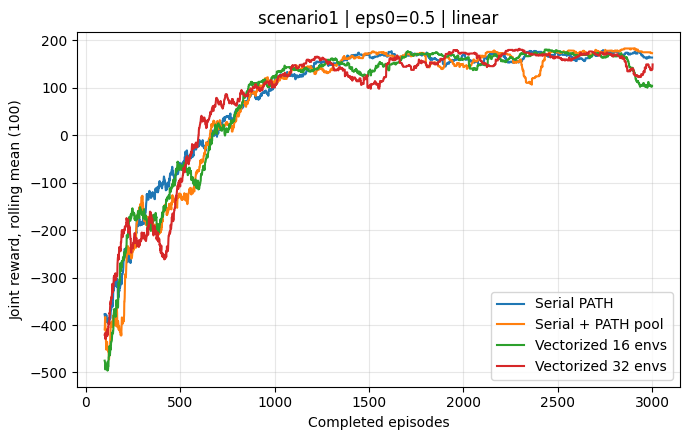

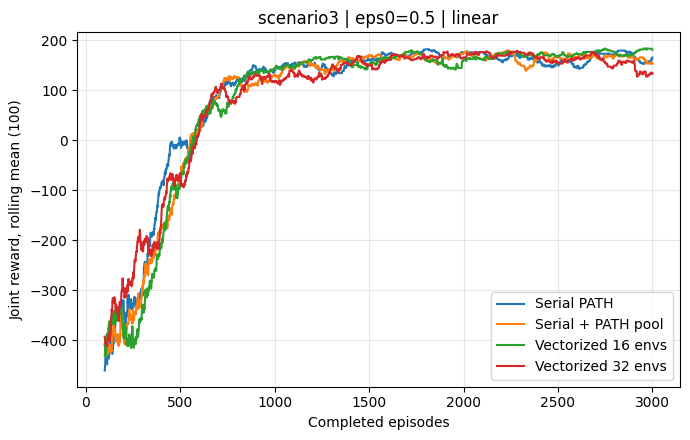

In [ ]:
def rolling_mean(values, window=100):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    window = max(1, min(int(window), values.size))
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


ROLLING_WINDOW = 100

for scenario_key in SCENARIOS:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for variant in RUN_VARIANTS:
        stats = results[scenario_key][variant["label"]]
        rewards = stats["rewards"]
        min_len = min(len(rewards[0]), len(rewards[1]))
        if min_len == 0:
            continue
        joint_reward = np.asarray(rewards[0][:min_len], dtype=float) + np.asarray(rewards[1][:min_len], dtype=float)
        smoothed = rolling_mean(joint_reward, window=ROLLING_WINDOW)
        x = np.arange(smoothed.size) + min(ROLLING_WINDOW, joint_reward.size)
        ax.plot(x, smoothed, label=CASE_LABELS[variant["label"]])
    ax.set_title(f"{scenario_key} | eps0={ROBUST_EPSILON_START:g} | {EPSILON_SCHEDULE}")
    ax.set_xlabel("Completed episodes")
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(f"Joint reward, rolling mean ({ROLLING_WINDOW})")
    ax.legend(loc="best")
    fig.tight_layout()
    plt.savefig(OUTPUT_ROOT / f"reward_curves_{scenario_key}.png")
    plt.show()
